# 05 · Evaluation, Stability & Fairness
Compare models, inspect curves, check the model is **stable** (train↔test gap), **calibrated** (probabilities are trustworthy), and **fair** across gender.

In [1]:
# Make `src` importable when running from the notebooks/ folder
import sys, os
sys.path.insert(0, os.path.abspath('..'))
import pandas as pd, numpy as np
pd.set_option('display.max_columns', 60)

In [2]:
import json, pandas as pd
from src import config
lb = pd.read_csv(config.METRICS_DIR/'model_comparison.csv')
lb.round(4)

,model,threshold,accuracy,balanced_accuracy,precision,recall,f1,roc_auc,pr_auc,brier,mcc,cv_roc_auc
0,stacking,0.5,0.8710,0.8292,0.5472,0.7697,0.6397,0.8970,0.7843,0.1058,0.5760,NaN
1,catboost,0.5,0.8855,0.8343,0.5891,0.7613,0.6642,0.8953,0.7799,0.1004,0.6037,0.8918
2,voting_soft,0.5,0.8988,0.8254,0.6422,0.7210,0.6793,0.8917,0.7732,0.0947,0.6209,NaN
3,xgboost,0.5,0.8948,0.8300,0.6236,0.7378,0.6759,0.8913,0.7739,0.0939,0.6167,0.8911
4,random_forest,0.5,0.9265,0.7939,0.8592,0.6050,0.7101,0.8909,0.7700,0.0730,0.6829,0.8818
5,hist_gradient_boosting,0.5,0.8922,0.8244,0.6168,0.7277,0.6677,0.8882,0.7640,0.1003,0.6069,0.8869
6,knn,0.5,0.8882,0.6285,0.9625,0.2588,0.4079,0.8773,0.7322,0.0807,0.4668,0.8645
7,logistic_regression,0.5,0.8142,0.7848,0.4283,0.7429,0.5433,0.8503,0.6145,0.1420,0.4632,0.8461


## Curves & diagnostics (saved by training)

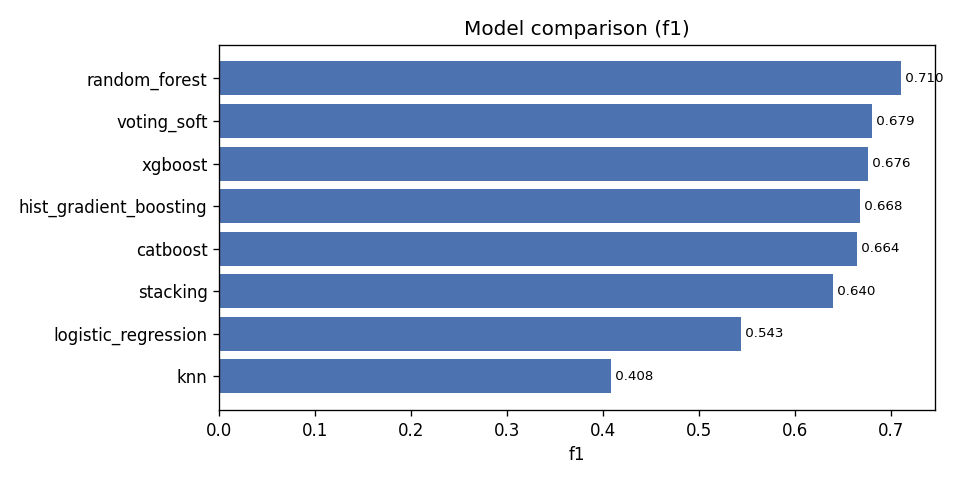

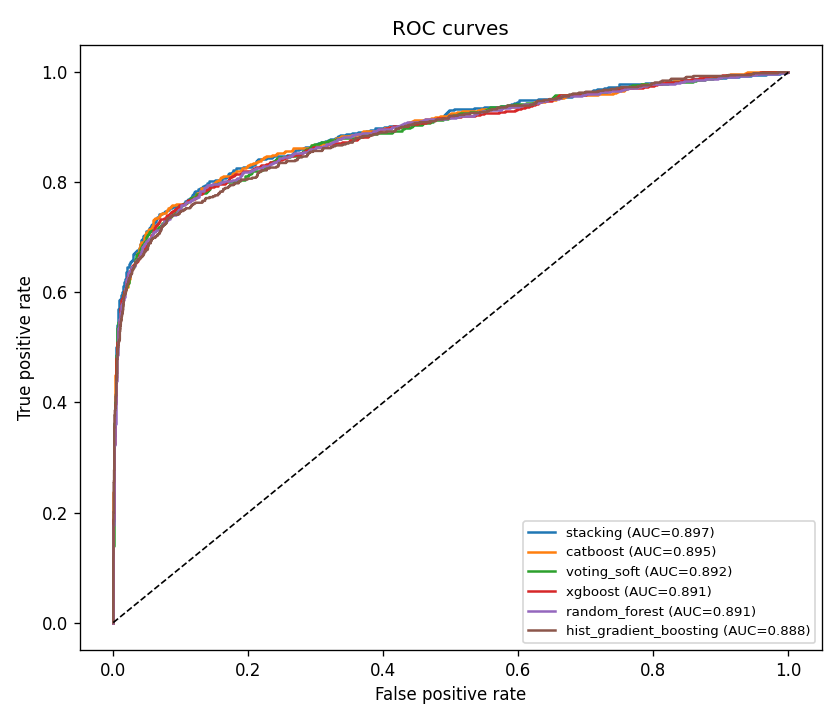

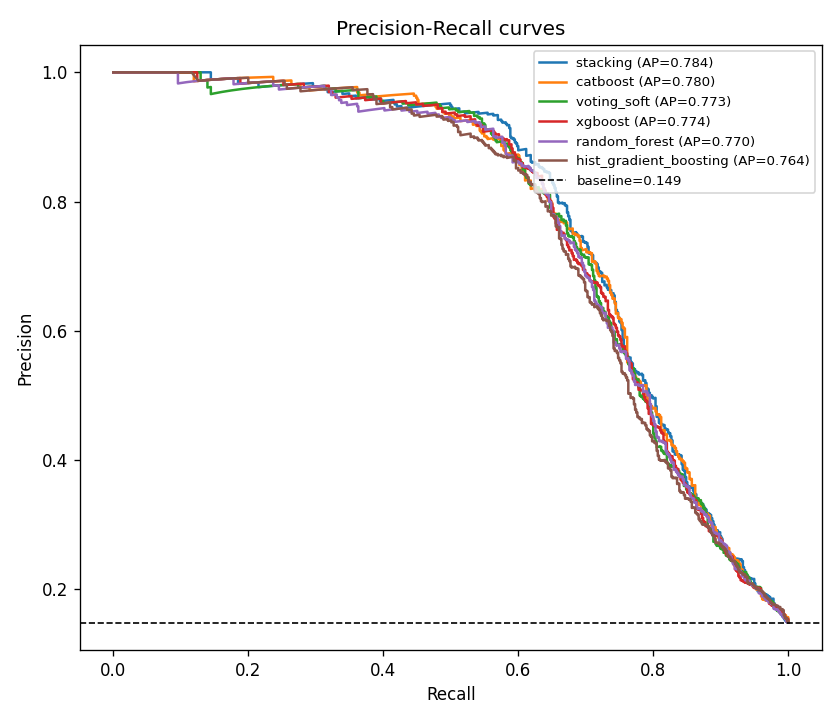

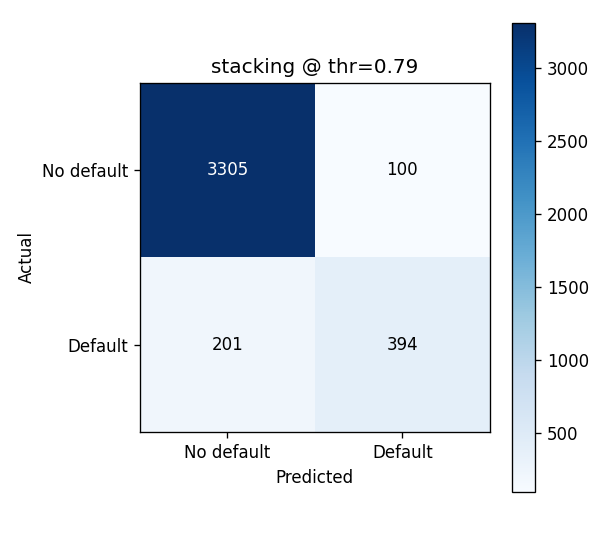

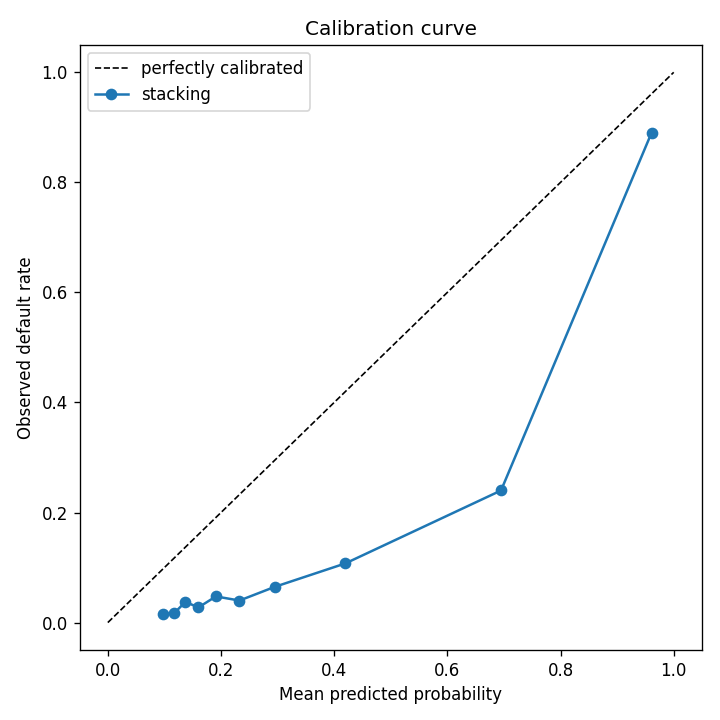

In [3]:
from IPython.display import Image, display
for f in ['model_comparison_f1.png','roc_curves.png','pr_curves.png',
          'confusion_matrix.png','calibration_curve.png']:
    p = config.FIGURES_DIR/f
    if p.exists(): display(Image(str(p)))

## Champion metrics + overfit check

In [4]:
meta = json.load(open(config.METADATA_ARTIFACT))
print('champion:', meta['model_name'], '| threshold:', round(meta['decision_threshold'],3))
print('test :', {k:round(v,4) for k,v in meta['test_metrics'].items()})
print('train:', {k:round(v,4) for k,v in meta['train_metrics'].items()})
print('overfit gap (roc_auc):', round(meta['test_metrics'].get('overfit_gap_roc_auc',0),4))

champion: stacking | threshold: 0.789
test : {'threshold': 0.7888, 'accuracy': 0.9247, 'balanced_accuracy': 0.8164, 'precision': 0.7976, 'recall': 0.6622, 'f1': 0.7236, 'roc_auc': 0.897, 'pr_auc': 0.7843, 'brier': 0.1058, 'mcc': 0.6844, 'overfit_gap_roc_auc': 0.0701}
train: {'threshold': 0.7888, 'accuracy': 0.9453, 'balanced_accuracy': 0.8696, 'precision': 0.8539, 'recall': 0.762, 'f1': 0.8053, 'roc_auc': 0.9671, 'pr_auc': 0.8992, 'brier': 0.0842, 'mcc': 0.7753}
overfit gap (roc_auc): 0.0701


> A small train↔test gap = not overfitting. A calibration curve near the diagonal = probabilities are not 'hallucinated'.

## Fairness audit

In [5]:
fair = json.load(open(config.REPORTS_DIR/'fairness_audit.json'))
for attr, rep in fair.items():
    print('==', attr, 'gaps:', rep['gaps'])
    display(pd.DataFrame(rep['by_group']).round(3))

== gender gaps: {'demographic_parity_diff': 0.04007961079168508, 'equal_opportunity_diff': 0.09756714060031602, 'fpr_diff': 0.013342365975765613}


,group,n,actual_default_rate,predicted_default_rate,tpr_recall,fpr,precision
0,female,1275,0.125,0.104,0.667,0.023,0.803
1,male,1395,0.161,0.123,0.613,0.028,0.807
2,other,1330,0.159,0.144,0.711,0.037,0.785
